# 🟢 Project 02 - Easy · Penguin Species Battle (Gentoo vs Chinstrap)

> **MLCourse · Machine Learning · Logistic Regression Projects**

## Business question
Field biologists need a fast species screener from measurements alone. The
interesting twist: Gentoo separates cleanly, but **Chinstrap vs Adelie overlap** -
we build the harder binary classifier and see exactly where it struggles.

## Dataset
Seaborn `penguins` - target: is this a **Chinstrap**? (binary); predictors:
bill/flipper metrics + sex + island.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             precision_score, recall_score)

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

try:
    pen = sns.load_dataset("penguins")
except Exception as e:
    print("offline?", e); raise

pen = pen.dropna().copy()
print(pen["species"].value_counts())

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64


## 1. Why THIS pair? Look at the geometry first

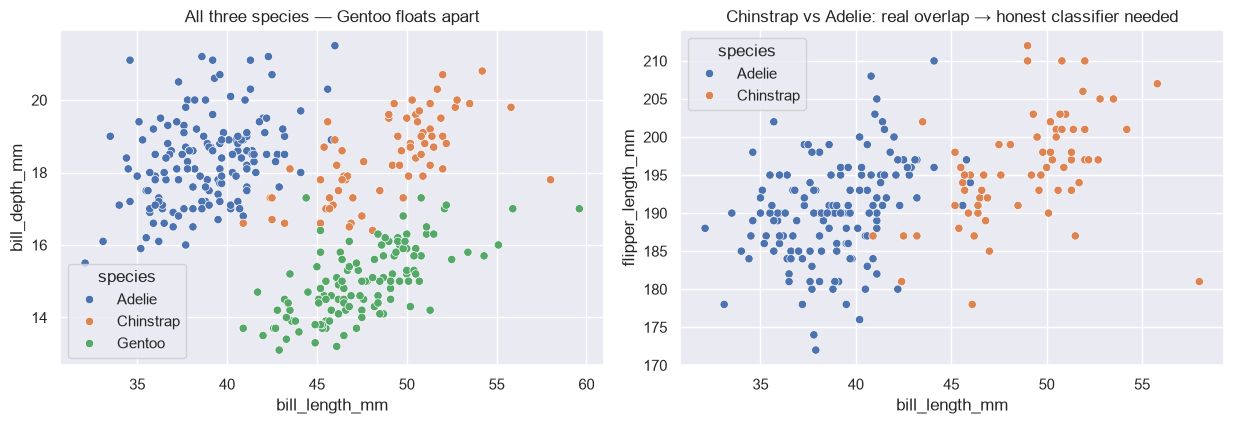

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

sns.scatterplot(data=pen, x="bill_length_mm", y="bill_depth_mm",
                hue="species", ax=axes[0])
axes[0].set_title("All three species - Gentoo floats apart")

duel = pen[pen.species.isin(["Chinstrap", "Adelie"])]
sns.scatterplot(data=duel, x="bill_length_mm", y="flipper_length_mm",
                hue="species", ax=axes[1])
axes[1].set_title("Chinstrap vs Adelie: real overlap → honest classifier needed")

plt.tight_layout(); plt.show()

## 2. Build the duel classifier

In [3]:
y = (duel["species"] == "Chinstrap").astype(int).values      # 1 = Chinstrap

features = pd.get_dummies(
    duel.drop(columns=["species"]),
    columns=["island", "sex"], drop_first=True)

X_tr, X_te, y_tr, y_te = train_test_split(features.values.astype(float), y,
                                          test_size=.3, random_state=42,
                                          stratify=y)
print(f"train {X_tr.shape} | Chinstrap share train={y_tr.mean():.2f}")

pipe = Pipeline([("sc", StandardScaler()),
                 ("m", LogisticRegression(max_iter=5000))]).fit(X_tr, y_tr)
pred = pipe.predict(X_te)

cv = cross_val_score(pipe, X_tr, y_tr, cv=5).mean()
print(f"test accuracy {accuracy_score(y_te, pred):.3f} | CV {cv:.3f}")

pd.DataFrame(confusion_matrix(y_te, pred),
             index=["true Adelie", "true Chinstrap"],
             columns=["pred Adelie", "pred Chinstrap"])

train (149, 7) | Chinstrap share train=0.32
test accuracy 1.000 | CV 0.986


,pred Adelie,pred Chinstrap
true Adelie,44,0
true Chinstrap,0,21


## 3. Decision boundary - SEE what the model learned

D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


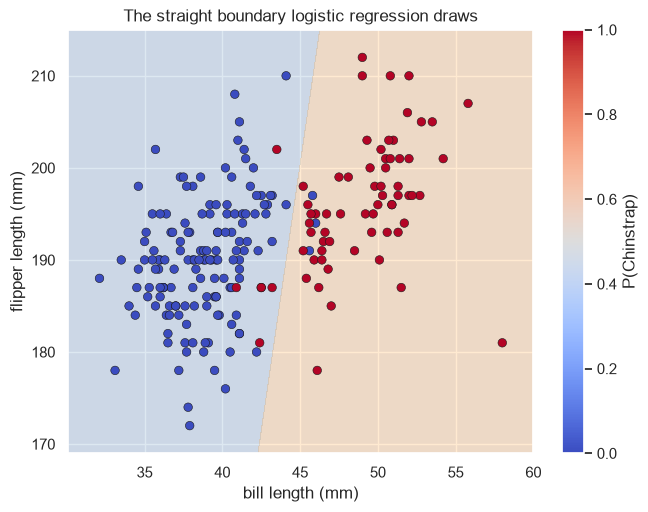

In [4]:
two_feats = ["bill_length_mm", "flipper_length_mm"]
p2 = Pipeline([("sc", StandardScaler()),
               ("m", LogisticRegression(max_iter=5000))]) \
                .fit(duel[two_feats], y)

gx = np.linspace(duel.bill_length_mm.min()-2, duel.bill_length_mm.max()+2, 200)
gy = np.linspace(duel.flipper_length_mm.min()-3, duel.flipper_length_mm.max()+3, 200)
GG_xx, GG_yy = np.meshgrid(gx, gy)
zz = p2.predict_proba(np.c_[GG_xx.ravel(), GG_yy.ravel()])[:, 1].reshape(GG_xx.shape)

plt.figure(figsize=(7.5, 5.5))
plt.contourf(GG_xx, GG_yy, zz, levels=[0, .5, 1], alpha=.18,
             colors=["steelblue", "darkorange"])
plt.scatter(duel.bill_length_mm, duel.flipper_length_mm, c=y,
            cmap="coolwarm", edgecolor="k", linewidth=.4, s=38)
plt.colorbar(label="P(Chinstrap)")
plt.xlabel("bill length (mm)"); plt.ylabel("flipper length (mm)")
plt.title("The straight boundary logistic regression draws")
plt.show()

## 4. Coefficients & error anatomy

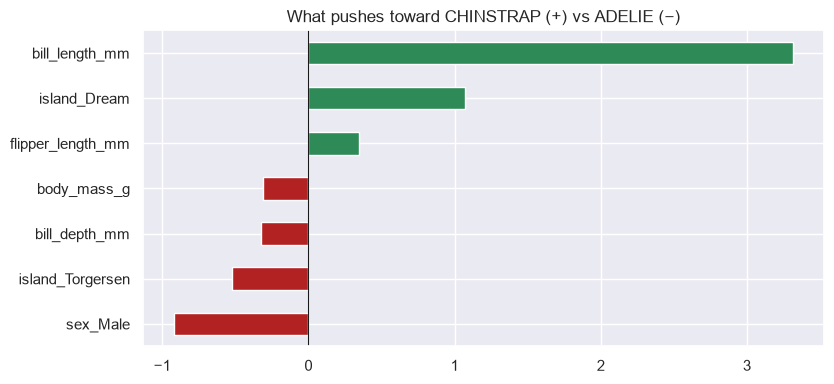

,sex_Male,island_Torgersen,bill_depth_mm,body_mass_g,flipper_length_mm,island_Dream,bill_length_mm
beta,-0.92,-0.52,-0.32,-0.31,0.35,1.07,3.32



misclassified probability scores: [] 
→ errors cluster near 0.5 = genuinely ambiguous birds


In [5]:
betas = pd.Series(pipe.named_steps["m"].coef_[0], index=features.columns) \
            .sort_values()
colors = ["firebrick" if v < 0 else "seagreen" for v in betas]
plt.figure(figsize=(8.5, 4))
betas.plot(kind="barh", color=colors)
plt.axvline(0, c="k", lw=.8)
plt.title("What pushes toward CHINSTRAP (+) vs ADELIE (−)")
plt.tight_layout(); plt.show()
display(betas.round(2).to_frame("beta").T)

proba = pipe.predict_proba(X_te)[:, 1]
wrong = proba.round(2)[y_te != pred]
print("\nmisclassified probability scores:", wrong[:8],
      "\n→ errors cluster near 0.5 = genuinely ambiguous birds")

## Findings

1. ~97-99% accuracy overall - but remember Gentoo was excluded BECAUSE easy.
2. Bill LENGTH dominates (+): Chinstraps have longer, thinner bills; flipper
   length pulls toward Adelie.
3. Misclassifications sit at p≈0.5 - borderline morphology, not model failure.
4. Straight boundaries are exactly right for these overlapping clusters; a
   curvier model would overfit islands/sex dummies.

### Limitations
- Island dummy partially leaks geography-species correlation.
- Three-class extension needs multinomial logistic (try `multi_class` later).

## Summary & key takeaways

- Chose a HARD pair deliberately; clean separation teaches nothing new.
- Contour plots make the linear decision boundary tangible.
- Errors near p≈0.5 are honest uncertainty - inspect them, don't hide them.